In [2]:
#### Necessary libraries ####

import numpy as np  # Numpy is the fundamental package for scientific computing in Python.
import pandas as pd
from Functions import *
import pylab
from combine_data import read_data, read_precip_era5, read_tracked_precip
from paths import basedir, figure_path
from sklearn.cluster import KMeans
import seaborn as sns
from eofs.xarray import Eof #Import eofs package

# The statement below enforces the plots to be put into this notebook, instead of in their own windows.
%matplotlib inline

In [9]:
# Some settings parameters for the clustering analysis and plotting
n_clusters = 2  # Number of clusters for KMeans
n_init = 100  # Number of initializations for KMeans    
n_pcs = 10  # Number of principal components to use for clustering
random_state = None  # Random state for reproducibility

normalize = False  # Whether to normalize the data before clustering
plot_clusters = True  # Whether to plot the clustering results  

In [10]:
# Settings 
cases = ["Pakistan","Australia","Scotland"]

# TODO: fix WAM2layers units (?)
list_reordered = [
    "WAM2layers",
    "2LDRM",
    #'UTrack Ens1',
    "UTrack Ens2",
    #'UTrack Ens3',
    #'UTrack Ens4',
    #'UTrack Ens5',
    "BTrIMS",
    "TRACMASS",
    #'FLEXPART-HAMSTER Ens1',
    #'FLEXPART-HAMSTER Ens2',
    #'FLEXPART-HAMSTER Ens3',
    #'FLEXPART-HAMSTER Ens4',
    "FLEXPART-SSW08 (HAMSTER) Ens5",
    "FLEXPART-SSW08 (WaterSip)",
    "FLEXPART-SSW08 (UniVie)",
    "LAGRANTO-SSW08",
    "FLEXPART-SSW08 (IBCAS)",
    "FLEXPART-SSW08 (HKUST) Ens2",
    "FLEXPART-SSW08 (LATTIN)",
    #'WRF-WVT',
    "FLEXPART-SJ04 (LATTIN)",
]

# Data loading & Calculation of clusters

In [ ]:
#Results storage
kmeans_results = {}
eofs_results = {}

# Loop over cases
for case in cases:
    print(f"Processing case: {case}")

    ########################################################
    ## import model runs                                  ##
    ########################################################
    ds_sources = read_data(basedir, case)

    ########################################################
    ## preprocess model runs                              ##
    ########################################################

    #### model runs for plotting ####
    all_maps = {kk: ds_sources[kk] for kk in list_reordered}
    all_maps = xr.Dataset(all_maps)

    #Select area of interest without nans
    if(case=="Pakistan"):
        #[20.0, 120.0, -30.0, 40.0]
        all_maps = all_maps.sel(lat=slice(-30, 40), lon=slice(20, 120))
    elif(case=="Australia"):
        #([-160.0, 180.0, -80.0, 20.0])
        all_maps = all_maps.sel(lat=slice(-80, 20), lon=slice(-160, 190))
    elif(case=="Scotland"):
        #[-100.0, 50.0, 5.0, 60.0]
        all_maps = all_maps.sel(lat=slice(5, 60), lon=slice(-100, 50))

    #Set nans to zero
    all_maps = all_maps.fillna(0)

    #Normalize data
    if(normalize):
        all_maps_nonnormalized = all_maps.copy()
        for model in all_maps.data_vars:
            data = all_maps[model].values
            data_min = np.min(data)
            data_max = np.max(data)
            all_maps[model].values = (data - data_min) / (data_max - data_min)
    
    ########################################################
    ## Clustering analysis                               ##
    ########################################################
    #Do a clustering analysis to group similar model runs together
    kmeans  = KMeans(n_clusters=n_clusters, n_init=n_init,random_state=random_state).fit(
        all_maps.to_array().transpose("variable", "lat", "lon").values.reshape(
            13, -1
        )
    )
    kmeans_results[case] = kmeans

    labels = kmeans.labels_
    for i, model in enumerate(all_maps.data_vars):
        print(f"{model}: Cluster {labels[i]}") 

    # Calculate cluster centers
    cluster_centers = kmeans.cluster_centers_.reshape(n_clusters, all_maps.lat.size, all_maps.lon.size)
    kmeans_results[case+'_centers'] = cluster_centers
    
    # Also save longitude and latitude grids for plotting
    kmeans_results[case+'_lat'] = all_maps.lat
    kmeans_results[case+'_lon'] = all_maps.lon

    # Calculate distances to cluster centers
    distances = kmeans.transform(
        all_maps.to_array().transpose("variable", "lat", "lon").values.reshape(
            13, -1
        )
    )
    kmeans_results[case+'_distances'] = distances
    
    ########################################################
    ## EOF analysis                                     ##
    ########################################################
    #Do an EOF analysis to find dominant patterns in model runs
    #solver = Eof(all_maps.to_array().transpose("variable", "lat", "lon"))
    #eofs_results[case] = solver.eofsAsCorrelation(neofs=3)
    #pcs = solver.pcs(npcs=3, pcscaling=1)
    #var_frac = solver.varianceFraction(neigs=3)

SyntaxError: invalid syntax (3711970158.py, line 62)

# PLOTS

<Figure size 640x480 with 0 Axes>

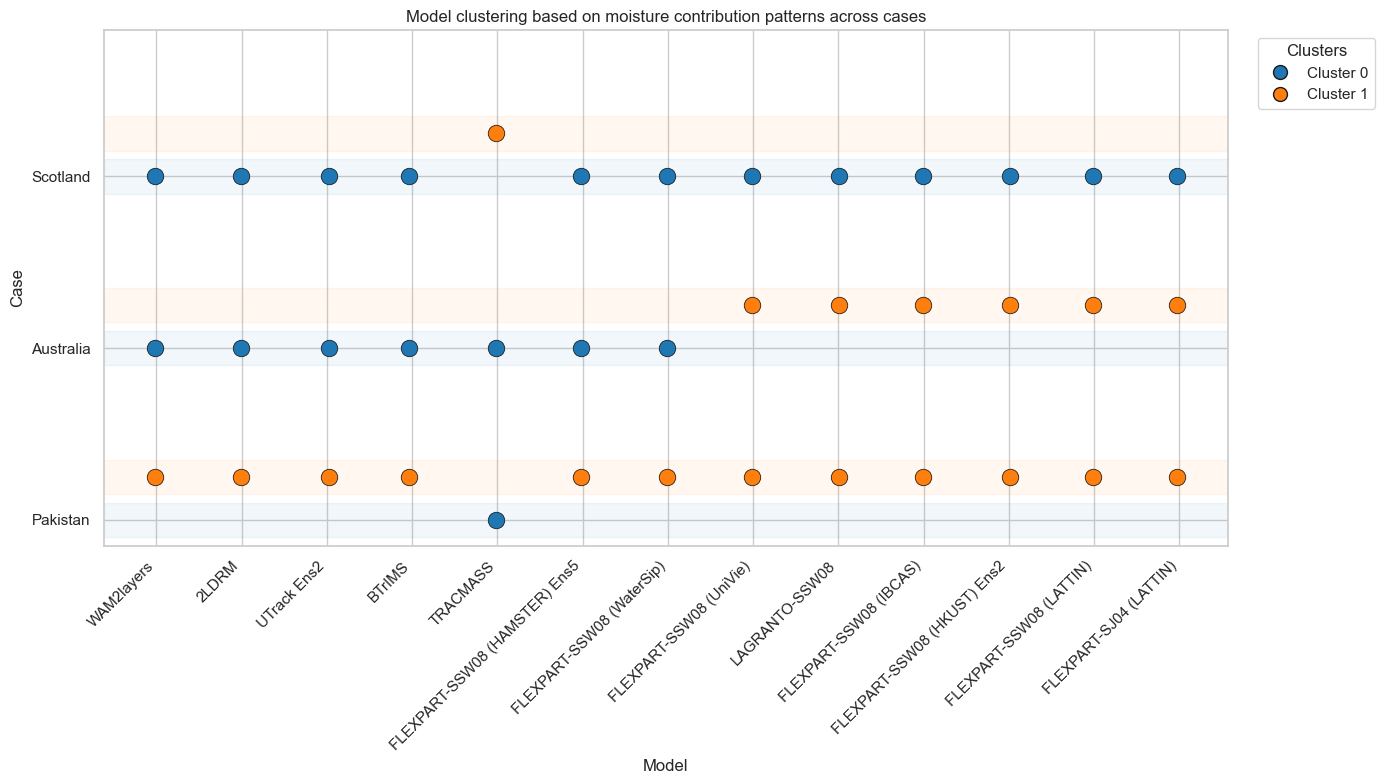

In [12]:
#Make a nicer plot to show which models are in which cluster for all cases
%matplotlib inline
sns.set(style="whitegrid", context="notebook")
plt.figure(figsize=(14, 8))
# Colors for clusters
palette = sns.color_palette("tab10", n_colors=3)    
x = np.arange(len(list_reordered))
# add a small jitter so labels don't overlap
jitter = (np.random.rand(len(x)) - 0.5) * 0.08
for case in cases:          
    kmeans = kmeans_results[case]
    labels = kmeans.labels_
    for i, model in enumerate(list_reordered):
        plt.scatter(i + jitter[i], labels[i] + (cases.index(case) * 4), s=140,
                    color=palette[labels[i]], edgecolor='k', linewidth=0.6)
    # draw horizontal bands for each cluster
    for cluster in np.unique(labels):
        plt.axhspan(cluster - 0.4 + (cases.index(case) * 4),
                    cluster + 0.4 + (cases.index(case) * 4),
                    color=palette[cluster], alpha=0.06)

# Annotate model names below the x-axis and rotate
plt.xticks(x, list_reordered, rotation=45, ha='right')  
# show integer y ticks for cluster indices
plt.yticks(np.arange(0, len(cases) * 4, 4), cases)
plt.ylim(-0.6, len(cases) * 4 - 0.6)
plt.xlabel("Model") 
plt.ylabel("Case")
plt.title("Model clustering based on moisture contribution patterns across cases")
# build a compact legend showing cluster colors
handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {c}',
                     markerfacecolor=palette[c], markersize=10, markeredgecolor='k')
           for c in np.unique(labels)]
plt.legend(handles=handles, title="Clusters", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
# save figure to figures path if available
try:
    plt.savefig(figure_path + '/cluster_assignment_all_cases.png', dpi=150, bbox_inches='tight')
except Exception:
    pass    

In [ ]:
# Make a plot of the cluster centers for each case
for case in cases:  
    kmeans = kmeans_results[case]
    cluster_centers = kmeans_results[case+'_centers']
    plt.figure(figsize=(12, 5))
    for i in range(n_clusters):
        plt.subplot(1, n_clusters, i + 1)
        plt.contourf(
            kmeans_results[case+'_lon'],
            kmeans_results[case+'_lat'],
            cluster_centers[i, :, :],
            levels=20,
            cmap="viridis",
        )
        plt.colorbar(label="Moisture Contribution")
        plt.title(f"Case: {case} - Cluster {i} Center")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
    plt.tight_layout()
    # save figure to figures path if available
    try:
        plt.savefig(figure_path + f'/cluster_centers_{case}.png', dpi=150, bbox_inches='tight')
    except Exception:
        pass
    plt.show()

TypeError: Length of x (601) must match number of columns in z (401)

# Old Plots

In [ ]:
#Make a plot to show which models are in which cluster for specific case
sns.set(style="whitegrid", context="notebook")
plt.figure(figsize=(12, 6))
# Colors for clusters
palette = sns.color_palette("tab10", n_colors=len(np.unique(labels)))
x = np.arange(len(all_maps.data_vars))
# add a small jitter so labels don't overlap
jitter = (np.random.rand(len(x)) - 0.5) * 0.08
for i, model in enumerate(all_maps.data_vars):
    plt.scatter(i + jitter[i], labels[i], s=140,
                color=palette[labels[i]], edgecolor='k', linewidth=0.6)
# draw horizontal bands for each cluster
for cluster in np.unique(labels):
    plt.axhspan(cluster - 0.4, cluster + 0.4,
                color=palette[cluster], alpha=0.06)

# Annotate model names below the x-axis and rotate
plt.xticks(x, all_maps.data_vars, rotation=45, ha='right')
# show integer y ticks for cluster indices
plt.yticks(np.unique(labels))
plt.ylim(-0.6, np.max(labels) + 0.6)
plt.xlabel("Model")
plt.ylabel("Cluster")
plt.title("Model clustering based on moisture contribution patterns")
# build a compact legend showing cluster colors
handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {c}',
                     markerfacecolor=palette[c], markersize=10, markeredgecolor='k')
           for c in np.unique(labels)]
plt.legend(handles=handles, title="Clusters", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
# save figure to figures path if available
try:
    plt.savefig(figure_path + '/cluster_assignment_' + case + '.png', dpi=150, bbox_inches='tight')
except Exception:
    pass
plt.show()


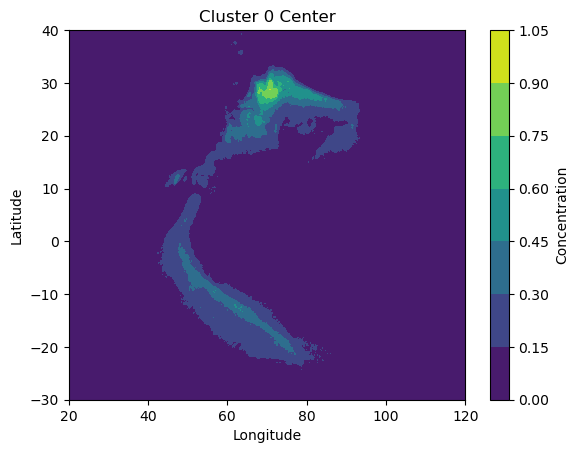

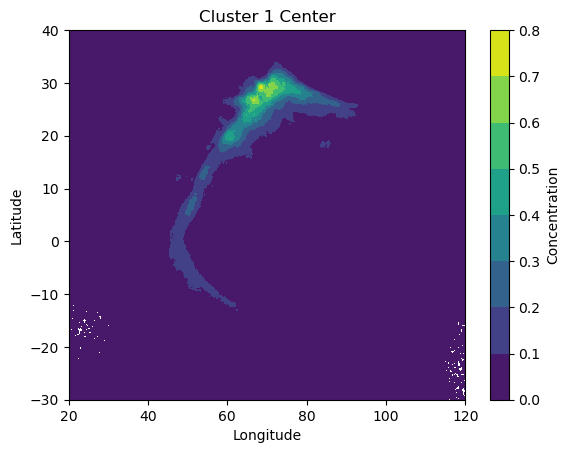

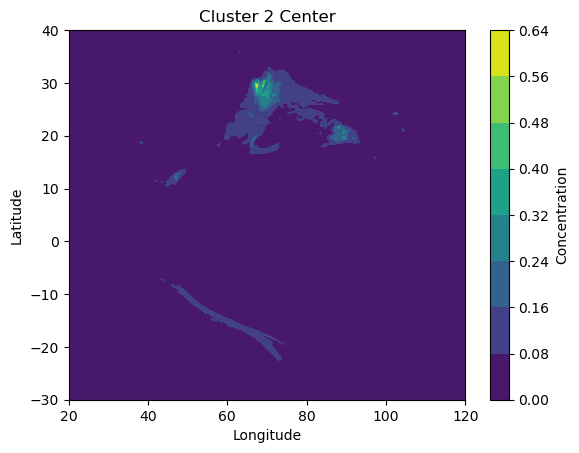

WAM2layers: Distances to centers [12.29447698 19.09131363 25.70050548]
2LDRM: Distances to centers [22.60168092 16.10604503 10.27338003]
UTrack Ens2: Distances to centers [24.05113891 14.98117044  5.05635107]
BTrIMS: Distances to centers [10.80008993 24.24913788 28.5061862 ]
TRACMASS: Distances to centers [30.67541461 18.88318407  7.83225743]
FLEXPART-SSW08 (HAMSTER) Ens5: Distances to centers [ 6.1438506  19.34562352 25.88909845]
FLEXPART-SSW08 (WaterSip): Distances to centers [16.68785557  9.38959652 22.53734265]
FLEXPART-SSW08 (UniVie): Distances to centers [20.479926    4.8696414  14.97904563]
LAGRANTO-SSW08: Distances to centers [15.7096797   7.89489056 18.75115738]
FLEXPART-SSW08 (IBCAS): Distances to centers [22.71347763  7.88102876 10.97777231]
FLEXPART-SSW08 (HKUST) Ens2: Distances to centers [22.6889178   6.79108071 12.50979418]
FLEXPART-SSW08 (LATTIN): Distances to centers [20.64423471  5.5409571  17.75544109]
FLEXPART-SJ04 (LATTIN): Distances to centers [21.31223293 12.6424

In [ ]:
# Calculate cluster centers
centers = kmeans.cluster_centers_.reshape(3, all_maps.lat.size, all_maps.lon.size)
# Plot cluster centers
for i, center in enumerate(centers):
    plt.figure()
    plt.contourf(all_maps.lon, all_maps.lat, center, cmap="viridis")
    plt.title(f"Cluster {i} Center")
    plt.colorbar(label="Concentration")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()


#Caclulate distances to cluster centers
distances = kmeans.transform(
    all_maps.to_array().transpose("variable", "lat", "lon").values.reshape(
        13, -1
    )
)   
for i, model in enumerate(all_maps.data_vars):
    dists = distances[i]
    print(f"{model}: Distances to centers {dists}")

array([[1.55035276e+03, 3.94253720e+02],
       [1.59671921e+03, 5.38053212e+02],
       [1.52280368e+03, 4.54837143e+02],
       [1.57673347e+03, 4.83857201e+02],
       [1.39849112e-04, 1.44999944e+03],
       [1.53161854e+03, 3.56941664e+02],
       [1.45576249e+03, 1.95221296e+02],
       [1.38764812e+03, 3.46872924e+02],
       [1.39312496e+03, 2.38281370e+02],
       [1.47299734e+03, 3.13936497e+02],
       [1.41731481e+03, 3.70723312e+02],
       [1.50823856e+03, 7.47943789e+02],
       [2.04322300e+03, 1.20983236e+03]])

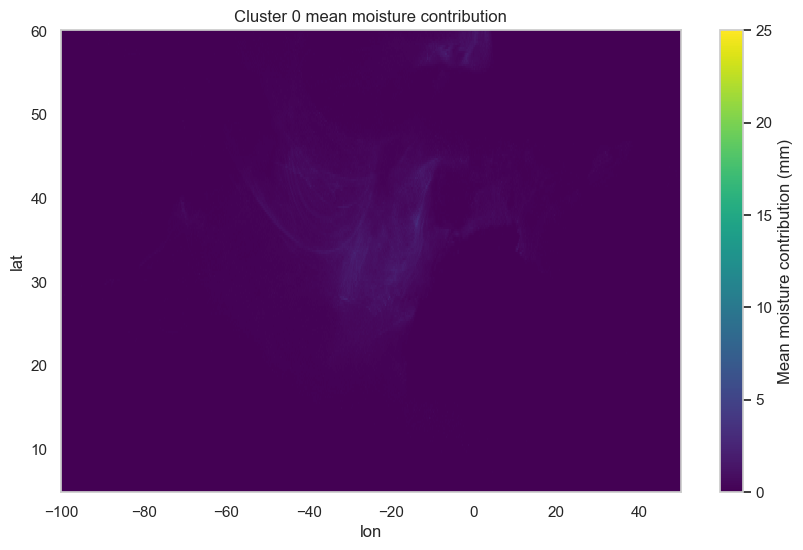

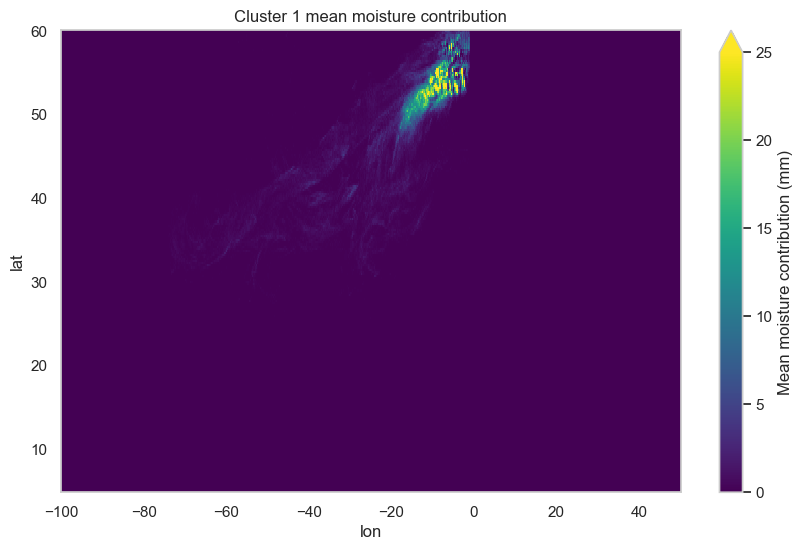

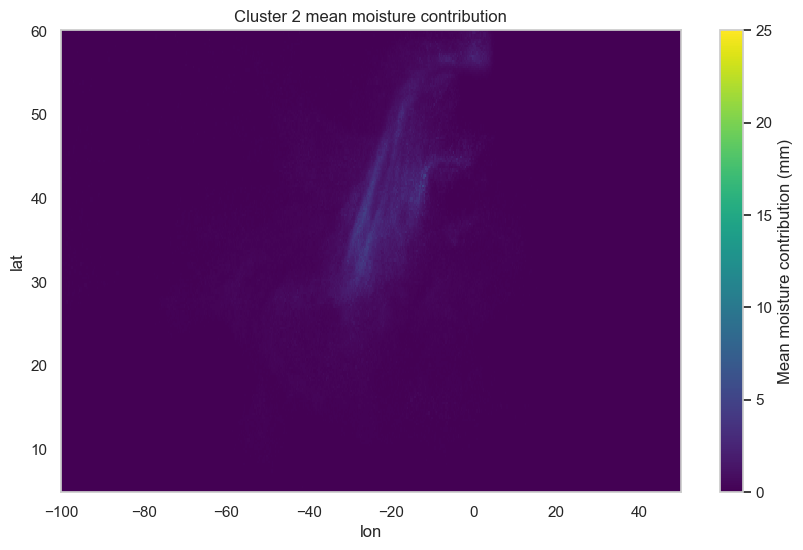

In [36]:
#Plot mean of different defined clusters
for cluster in np.unique(labels):
    plt.figure(figsize=(10, 6))
    cluster_members = [
        model
        for i, model in enumerate(all_maps.data_vars)
        if labels[i] == cluster
    ]
    cluster_mean = all_maps[cluster_members].to_array(dim='new').mean('new')
    cluster_mean.plot(
        cmap="viridis",
        vmin=0,
        vmax=25,
        cbar_kwargs={"label": "Mean moisture contribution (mm)"},
    )   

    plt.title(f"Cluster {cluster} mean moisture contribution")
    plt.show()

